# Trial-Averaged XSENS vs Vicon Agreement

This notebook compares XSENS-derived features against rebuilt Vicon marker annotations after averaging repeated trials.

- Keeps only SRS stroke participants.
- Uses `Vicon - Annotations_long.csv`, rebuilt from raw Vicon CSV trials.
- Uses trial-level XSENS results from `XSENS_results/`.
- Averages repeated trials within each `subject_id + visit_id + activity` for both Vicon and XSENS.
- Matches averaged rows by `subject_id`, `visit_id`, and `activity`.
- Shows visit-level errors, scatter plots, and Bland-Altman plots.


In [1]:
from pathlib import Path
import sys
import pandas as pd

cwd = Path.cwd()
if (cwd / "agreement_plots.py").exists():
    sys.path.insert(0, str(cwd))
elif (cwd / "Sensors_Visualizers" / "agreement_plots.py").exists():
    sys.path.insert(0, str(cwd / "Sensors_Visualizers"))

from agreement_plots import SPECS, all_metric_summary, display_feature_report, participant_agreement_table

pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 3)
pd.set_option("display.float_format", lambda value: f"{value:.3f}")

spec_by_title = {spec.title: spec for spec in SPECS}
print("Setup complete")

Setup complete


## Metric Summary

Use this table to decide which features are strongest before showing the plots.

In [2]:
summary = all_metric_summary()
display(summary.sort_values(["activity", "feature"]))

,activity,feature,xsens_column,vicon_column,unit,n,mae,rmse,bias,pearson_r,icc_2_1
3,left_turn,Left Turn Duration,sacrum_duration_s,duration_s,s,12,1.888,2.050,1.857,0.951,0.746
4,left_turn,Left Turn Step Count,sacrum_step_count,step_count,steps,12,1.333,1.683,-0.333,0.867,0.805
5,right_turn,Right Turn Duration,sacrum_duration_s,duration_s,s,14,1.837,2.072,0.857,0.845,0.797
6,right_turn,Right Turn Step Count,sacrum_step_count,step_count,steps,14,1.786,2.220,0.071,0.736,0.750
7,sit_to_stand,Sit-to-Stand Duration,sacrum_duration_s,duration_s,s,15,0.571,0.727,-0.229,0.496,0.458
1,walk,Walking 10-Step Cadence,sacrum_cadence_steps_min,cadence_steps_min,steps/min,16,10.817,13.963,-0.252,0.754,0.765
0,walk,Walking 10-Step Duration,sacrum_duration_s,duration_s,s,16,0.928,1.188,-0.006,0.772,0.781
2,walk,Walking 10-Step Mean Step Time,sacrum_mean_step_time_s,mean_step_time_s,s,16,0.093,0.119,-0.001,0.773,0.781


## Walking 10-Step Duration

,n,mae,rmse,bias,pearson_r,icc_2_1
0,16,0.928,1.188,-0.006,0.772,0.781


,subject_id,visit_id,activity,vicon,xsens,xsens_raw,error,abs_error,percent_error
0,SRS01,V01,walk,5.440,4.830,4.830,-0.610,0.610,11.213
1,SRS02,V01,walk,5.190,6.610,6.610,1.420,1.420,27.360
2,SRS03,V01,walk,6.800,7.300,7.300,0.500,0.500,7.353
3,SRS04,V01,walk,8.330,8.730,8.730,0.400,0.400,4.802
4,SRS05,V01,walk,6.070,6.190,6.190,0.120,0.120,1.977
5,SRS07,V01,walk,9.525,10.410,10.410,0.885,0.885,9.291
6,SRS08,V01,walk,5.445,5.620,5.620,0.175,0.175,3.214
7,SRS09,V01,walk,5.685,5.590,5.590,-0.095,0.095,1.671
8,SRS10,V01,walk,6.515,5.110,5.110,-1.405,1.405,21.566
9,SRS12,V01,walk,9.615,9.240,9.240,-0.375,0.375,3.900


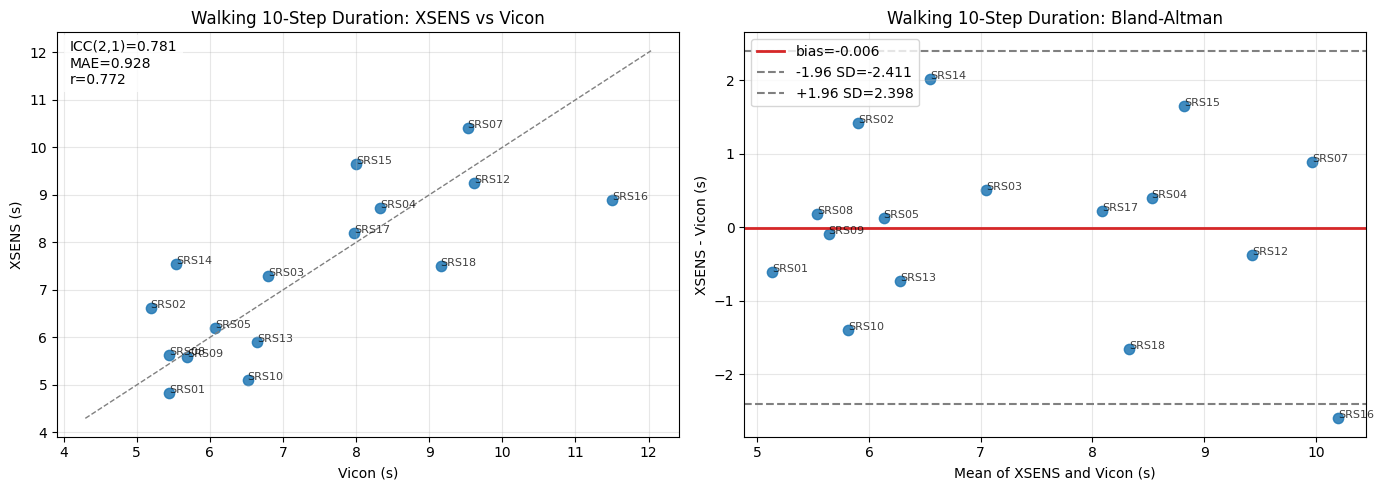

In [3]:
display_feature_report(spec_by_title["Walking 10-Step Duration"])

## Walking 10-Step Cadence

,n,mae,rmse,bias,pearson_r,icc_2_1
0,16,10.817,13.963,-0.252,0.754,0.765


,subject_id,visit_id,activity,vicon,xsens,xsens_raw,error,abs_error,percent_error
0,SRS01,V01,walk,110.294,124.224,124.224,13.930,13.930,12.630
1,SRS02,V01,walk,115.607,90.772,90.772,-24.835,24.835,21.482
2,SRS03,V01,walk,88.235,82.192,82.192,-6.043,6.043,6.849
3,SRS04,V01,walk,72.029,68.729,68.729,-3.300,3.300,4.581
4,SRS05,V01,walk,98.847,96.931,96.931,-1.916,1.916,1.938
5,SRS07,V01,walk,62.992,57.637,57.637,-5.355,5.355,8.501
6,SRS08,V01,walk,110.193,106.762,106.762,-3.431,3.431,3.114
7,SRS09,V01,walk,105.541,107.335,107.335,1.794,1.794,1.700
8,SRS10,V01,walk,92.095,117.417,117.417,25.322,25.322,27.496
9,SRS12,V01,walk,62.402,64.935,64.935,2.533,2.533,4.059


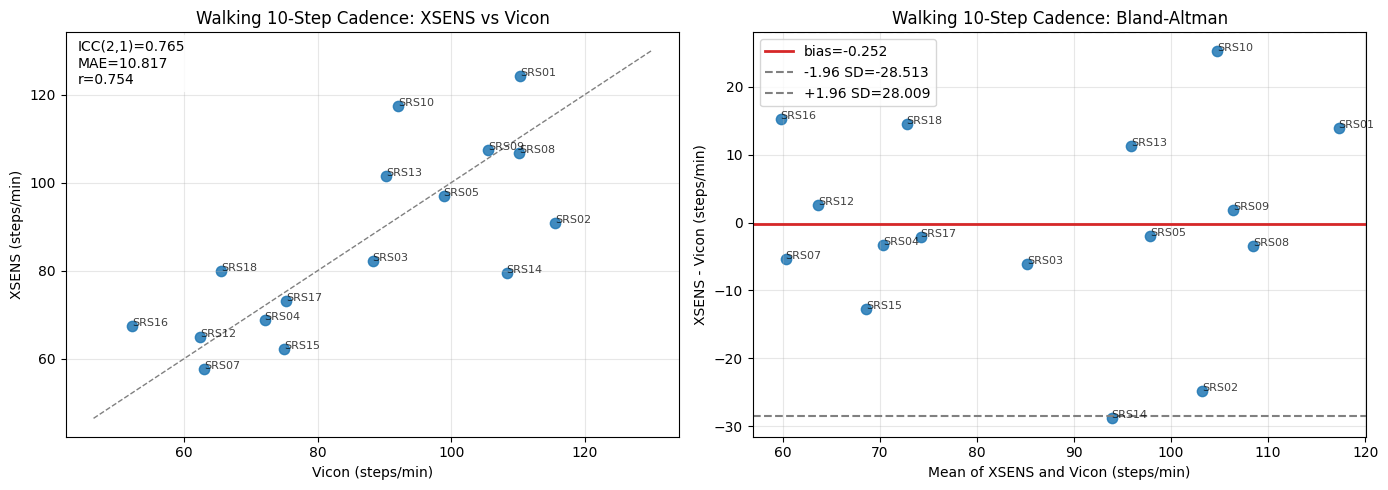

In [4]:
display_feature_report(spec_by_title["Walking 10-Step Cadence"])

## Left Turn Duration

,n,mae,rmse,bias,pearson_r,icc_2_1
0,12,1.888,2.050,1.857,0.951,0.746


,subject_id,visit_id,activity,vicon,xsens,xsens_raw,error,abs_error,percent_error
0,SRS01,V01,left_turn,5.500,6.900,6.900,1.400,1.400,25.455
1,SRS05,V01,left_turn,7.500,7.310,7.310,-0.190,0.190,2.533
2,SRS08,V01,left_turn,5.100,6.430,6.430,1.330,1.330,26.078
3,SRS09,V01,left_turn,5.000,7.710,7.710,2.710,2.710,54.200
4,SRS10,V01,left_turn,3.900,5.620,5.620,1.720,1.720,44.103
5,SRS12,V01,left_turn,8.000,10.360,10.360,2.360,2.360,29.500
6,SRS13,V01,left_turn,5.200,6.760,6.760,1.560,1.560,30.000
7,SRS14,V01,left_turn,9.800,12.540,12.540,2.740,2.740,27.959
8,SRS15,V01,left_turn,9.800,11.540,11.540,1.740,1.740,17.755
9,SRS16,V01,left_turn,6.500,9.040,9.040,2.540,2.540,39.077


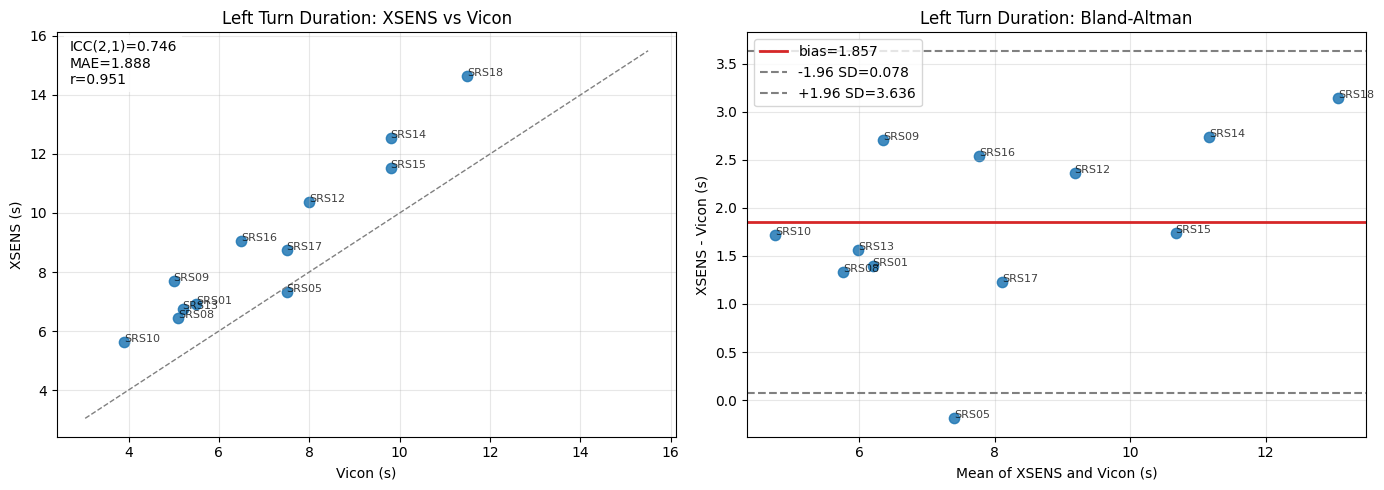

In [5]:
display_feature_report(spec_by_title["Left Turn Duration"])

## Left Turn Step Count

,n,mae,rmse,bias,pearson_r,icc_2_1
0,12,1.333,1.683,-0.333,0.867,0.805


,subject_id,visit_id,activity,vicon,xsens,xsens_raw,error,abs_error,percent_error
0,SRS01,V01,left_turn,9.000,8.000,8.000,-1.000,1.000,11.111
1,SRS05,V01,left_turn,9.000,8.000,8.000,-1.000,1.000,11.111
2,SRS08,V01,left_turn,8.000,7.000,7.000,-1.000,1.000,12.500
3,SRS09,V01,left_turn,8.000,8.000,8.000,0.000,0.000,0.000
4,SRS10,V01,left_turn,8.000,5.000,5.000,-3.000,3.000,37.500
5,SRS12,V01,left_turn,9.000,12.000,12.000,3.000,3.000,33.333
6,SRS13,V01,left_turn,9.000,7.000,7.000,-2.000,2.000,22.222
7,SRS14,V01,left_turn,13.000,13.000,13.000,0.000,0.000,0.000
8,SRS15,V01,left_turn,12.000,13.000,13.000,1.000,1.000,8.333
9,SRS16,V01,left_turn,12.000,10.000,10.000,-2.000,2.000,16.667


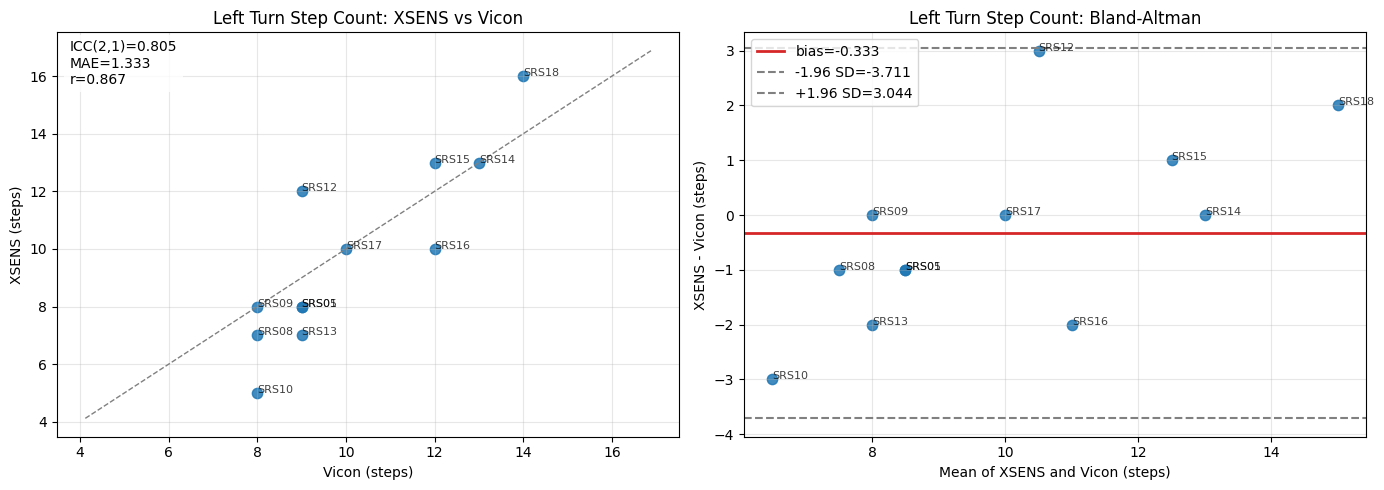

In [6]:
display_feature_report(spec_by_title["Left Turn Step Count"])

## Right Turn Duration

,n,mae,rmse,bias,pearson_r,icc_2_1
0,14,1.837,2.072,0.857,0.845,0.797


,subject_id,visit_id,activity,vicon,xsens,xsens_raw,error,abs_error,percent_error
0,SRS01,V01,right_turn,5.900,7.400,7.400,1.500,1.500,25.424
1,SRS04,V01,right_turn,11.000,12.130,12.130,1.130,1.130,10.273
2,SRS05,V01,right_turn,11.000,11.470,11.470,0.470,0.470,4.273
3,SRS07,V01,right_turn,12.300,9.630,9.630,-2.670,2.670,21.707
4,SRS08,V01,right_turn,5.400,7.530,7.530,2.130,2.130,39.444
5,SRS09,V01,right_turn,4.700,6.430,6.430,1.730,1.730,36.809
6,SRS10,V01,right_turn,4.500,6.480,6.480,1.980,1.980,44.000
7,SRS12,V01,right_turn,9.900,10.750,10.750,0.850,0.850,8.586
8,SRS13,V01,right_turn,4.100,6.010,6.010,1.910,1.910,46.585
9,SRS14,V01,right_turn,13.100,14.570,14.570,1.470,1.470,11.221


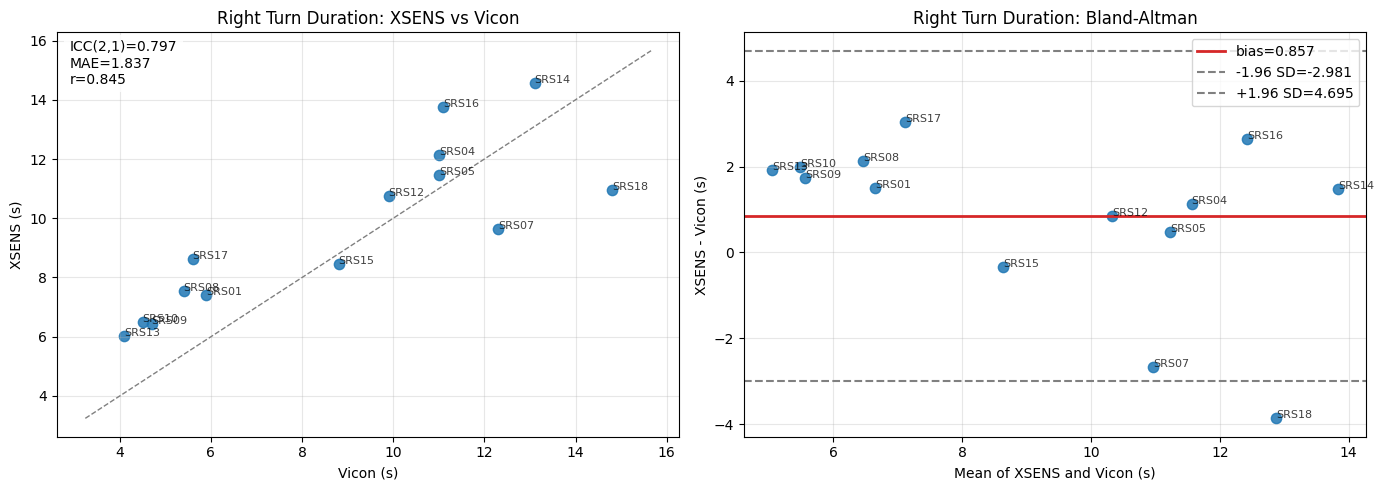

In [7]:
display_feature_report(spec_by_title["Right Turn Duration"])

## Right Turn Step Count

,n,mae,rmse,bias,pearson_r,icc_2_1
0,14,1.786,2.220,0.071,0.736,0.750


,subject_id,visit_id,activity,vicon,xsens,xsens_raw,error,abs_error,percent_error
0,SRS01,V01,right_turn,10.000,8.000,8.000,-2.000,2.000,20.000
1,SRS04,V01,right_turn,9.000,12.000,12.000,3.000,3.000,33.333
2,SRS05,V01,right_turn,10.000,10.000,10.000,0.000,0.000,0.000
3,SRS07,V01,right_turn,13.000,11.000,11.000,-2.000,2.000,15.385
4,SRS08,V01,right_turn,6.000,9.000,9.000,3.000,3.000,50.000
5,SRS09,V01,right_turn,8.000,10.000,10.000,2.000,2.000,25.000
6,SRS10,V01,right_turn,8.000,7.000,7.000,-1.000,1.000,12.500
7,SRS12,V01,right_turn,13.000,11.000,11.000,-2.000,2.000,15.385
8,SRS13,V01,right_turn,6.000,7.000,7.000,1.000,1.000,16.667
9,SRS14,V01,right_turn,15.000,19.000,19.000,4.000,4.000,26.667


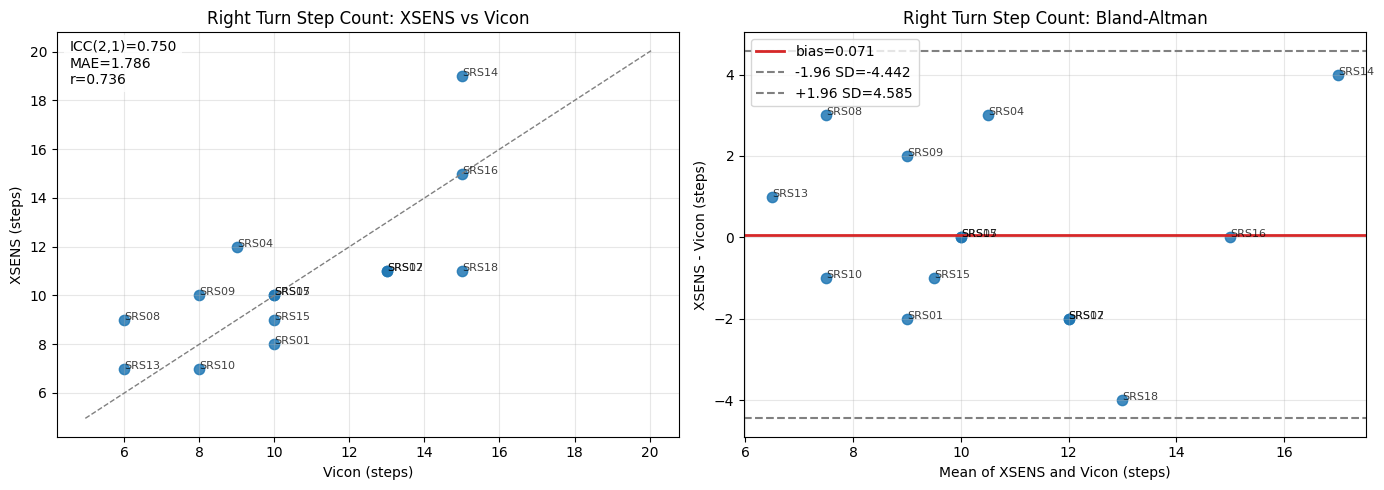

In [8]:
display_feature_report(spec_by_title["Right Turn Step Count"])

## Sit-to-Stand Duration

,n,mae,rmse,bias,pearson_r,icc_2_1
0,15,0.571,0.727,-0.229,0.496,0.458


,subject_id,visit_id,activity,vicon,xsens,xsens_raw,error,abs_error,percent_error
0,SRS01,V01,sit_to_stand,1.000,1.270,1.270,0.270,0.270,27.000
1,SRS03,V01,sit_to_stand,1.300,1.020,1.020,-0.280,0.280,21.538
2,SRS04,V01,sit_to_stand,2.300,1.130,1.130,-1.170,1.170,50.870
3,SRS05,V01,sit_to_stand,2.300,1.110,1.110,-1.190,1.190,51.739
4,SRS07,V01,sit_to_stand,2.200,2.210,2.210,0.010,0.010,0.455
5,SRS08,V01,sit_to_stand,1.200,1.170,1.170,-0.030,0.030,2.500
6,SRS09,V01,sit_to_stand,1.300,1.300,1.300,0.000,0.000,0.000
7,SRS10,V01,sit_to_stand,2.400,1.430,1.430,-0.970,0.970,40.417
8,SRS12,V01,sit_to_stand,1.200,1.810,1.810,0.610,0.610,50.833
9,SRS13,V01,sit_to_stand,1.100,0.870,0.870,-0.230,0.230,20.909


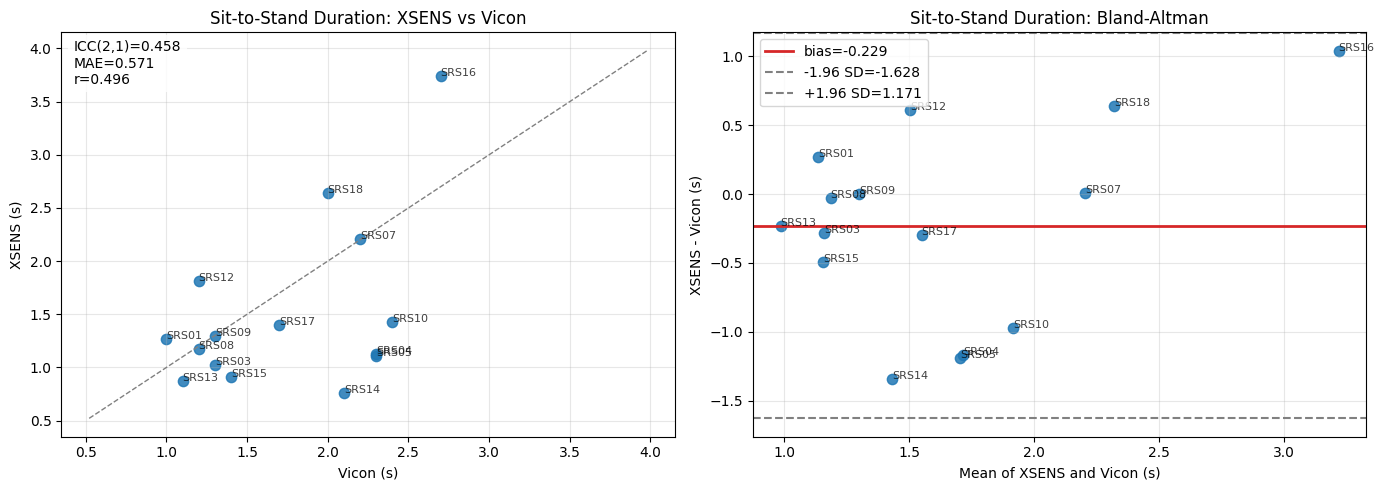

In [9]:
display_feature_report(spec_by_title["Sit-to-Stand Duration"])